# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ravindrathalari06/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

Which content items should be prioritized for human review based on observable signals such as search visibility, freshness, search position, CTR, and content depth?

### Decision supported

The analysis supports a content team's decision about **which pages to investigate first**. The resulting ranking is a decision-support queue: higher baseline action scores indicate higher priority for review, but they do not guarantee that taking an action will improve performance.


In [8]:
# Capstone Section 1: Question
# Establish the dataset and the decision target.

from datasets import load_dataset
import pandas as pd
import numpy as np

dataset = load_dataset("FlyRank/internship-starter")
df = dataset["train"].to_pandas()

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nDecision supported:")
print("Which content items should be investigated first?")

print("\nResearch question:")
print(
    "Which content items should be prioritized for human review "
    "using observable search and content signals?"
)

Rows: 30000
Columns: 53

Decision supported:
Which content items should be investigated first?

Research question:
Which content items should be prioritized for human review using observable search and content signals?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

The analysis uses the public-safe FlyRank internship dataset loaded from the `FlyRank/internship-starter` release. The observed working dataset contains 30,000 content items and 53 columns in this notebook.

The unit of analysis is one content item per row. The analysis uses search-performance, engagement, freshness, position, and content-depth signals. Target-derived fields such as `trend_direction` and `trend_pct` are not used as model features.

The data is anonymized and does not contain client names, URLs, or private search queries. No private client data is added to the analysis.


In [9]:
# Capstone Section 2: Data
# Verify dataset size, unit of analysis, and target distribution.

print("Dataset shape:", df.shape)
print("Rows / content items:", len(df))
print("Unique content IDs:", df["content_id"].nunique())

print("\nUnit of analysis:")
print("One row represents one content item.")

print("\nTarget source:")
print("trend_direction")

print("\nObserved trend_direction distribution:")
display(
    df["trend_direction"]
    .value_counts(dropna=False)
)

print("\nTarget-derived fields excluded from model features:")
print(["trend_direction", "trend_pct"])

Dataset shape: (30000, 53)
Rows / content items: 30000
Unique content IDs: 30000

Unit of analysis:
One row represents one content item.

Target source:
trend_direction

Observed trend_direction distribution:


,count
trend_direction,
down,16262
stable,5962
up,4388
new,2236
flat,1152



Target-derived fields excluded from model features:
['trend_direction', 'trend_pct']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

The modeling task uses a binary declining-content label defined as `trend_direction == "down"`. The model uses observable search, engagement, content, and freshness features available before the decision.

The learned model is Logistic Regression with median imputation and standardization for numeric features and most-frequent imputation with one-hot encoding for categorical features.

The validation design holds out clients rather than randomly splitting rows. The evaluated split contains 25 training clients and 7 test clients, with 26,496 training rows and 3,504 test rows. No client appears in both sets.

The ranking metric is Precision@50 because the practical decision is to identify a small set of pages for investigation first.

The final feature set contains 38 fields. Target-related fields, content IDs, and client IDs are excluded from the model features to reduce direct target or identity leakage.


In [10]:
# Capstone Section 3: Methodology
# Recreate the validated ML-09 grouped client setup.

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# ---------------------------------------------------------
# Label
# ---------------------------------------------------------

df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

# ---------------------------------------------------------
# Exact 38-feature set used in ML-09
# ---------------------------------------------------------

feature_fields = [
    "search_volume",
    "competition",
    "competition_level",
    "cpc",
    "content_type",
    "main_intent",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier",
    "age_tier_order",
    "days_since_last_update",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "impression_tier",
    "position_tier"
]

# ---------------------------------------------------------
# Leakage check
# ---------------------------------------------------------

forbidden_fields = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "content_id",
    "client_id"
]

leakage_fields = [
    col for col in feature_fields
    if col in forbidden_fields
]

print("Final feature count:", len(feature_fields))
print("Potential leakage fields found:", leakage_fields)

# ---------------------------------------------------------
# Grouped client split
# ---------------------------------------------------------

clients = df["client_id"].unique()

train_clients, test_clients = train_test_split(
    clients,
    test_size=0.20,
    random_state=123
)

train_df = df[
    df["client_id"].isin(train_clients)
].copy()

test_df = df[
    df["client_id"].isin(test_clients)
].copy()

print("\nTraining clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

client_overlap = (
    set(train_clients) & set(test_clients)
)

print("Client overlap:", len(client_overlap))

assert len(client_overlap) == 0

# ---------------------------------------------------------
# Prepare model data
# ---------------------------------------------------------

X_train = train_df[feature_fields]
X_test = test_df[feature_fields]

y_train = train_df["is_declining_label"]
y_test = test_df["is_declining_label"]

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = [
    c for c in feature_fields
    if c not in numeric_features
]

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features
    ),
    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore")
            )
        ]),
        categorical_features
    )
])

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

scores = model.predict_proba(X_test)[:, 1]

print("\nModel trained successfully.")
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Final feature count: 38
Potential leakage fields found: []

Training clients: 25
Test clients: 7
Training rows: 26496
Test rows: 3504
Client overlap: 0

Model trained successfully.
Numeric features: 29
Categorical features: 9


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

Under the grouped client-holdout validation used in ML-09, the Logistic Regression model achieved a measured Precision@50 of **1.00**. The previously measured Week-4 hand-written baseline achieved **0.46** on its evaluated result.

The model result therefore represents a measured improvement of **0.54 Precision@50 points** over the baseline result used in the validation audit.

The Week-5 model result was also 1.00, so the measured Precision@50 did not change between the original Week-5 evaluation and the ML-09 grouped validation in this analysis.

These numbers are observed results on the evaluated dataset and splits. They are not evidence that the same performance will occur on future or unseen production data.


In [11]:
# Capstone Section 4: Results
# Reproduce the ML-09 Precision@50 calculation.

def precision_at_50(y_true, scores):
    top_50 = scores.argsort()[::-1][:50]
    return y_true.iloc[top_50].mean()

honest_precision = precision_at_50(
    y_test.reset_index(drop=True),
    scores
)

# Previously measured values from ML-09
week5_precision = 1.00
week4_baseline_precision = 0.46

print("===== RESULTS =====")

print(
    "Week-5 learned model Precision@50:",
    week5_precision
)

print(
    "ML-09 grouped Precision@50:",
    round(honest_precision, 4)
)

print(
    "Week-4 baseline Precision@50:",
    week4_baseline_precision
)

print(
    "Model vs baseline improvement:",
    round(
        honest_precision - week4_baseline_precision,
        4
    )
)

print(
    "Week-5 to ML-09 change:",
    round(
        honest_precision - week5_precision,
        4
    )
)

print("\nValidation:")
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Client overlap:", len(client_overlap))

===== RESULTS =====
Week-5 learned model Precision@50: 1.0
ML-09 grouped Precision@50: 1.0
Week-4 baseline Precision@50: 0.46
Model vs baseline improvement: 0.54
Week-5 to ML-09 change: 0.0

Validation:
Training clients: 25
Test clients: 7
Training rows: 26496
Test rows: 3504
Client overlap: 0


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis has several limits. The dataset represents an observed set of anonymized content items, so the results should not be treated as universal evidence about search performance.

Precision@50 measures how many of the top 50 ranked items match the declining-content label in the evaluated test set. It does not measure whether a recommended content change will improve traffic, rankings, CTR, or business outcomes.

The validation uses client grouping, which reduces row-level leakage across clients, but it does not establish future-time performance. Search behavior, content, and measurement conditions can change.

The ML-10 action queue is based on a transparent baseline score and observable signals. A high score means higher priority for human review; it does not mean that a particular intervention is guaranteed to work.

Human review remains necessary before publishing, deleting, redirecting, rewriting, or otherwise changing content.


In [12]:
# Capstone Section 5: Limitations
# Code-backed checks for the main limitations.

print("Dataset rows:", len(df))
print("Test rows:", len(test_df))

print("\nValidation design:")
print("Client overlap:", len(client_overlap))

print("\nMetric:")
print("Precision@50 evaluates ranking quality for the top 50 items.")
print("It does not directly measure business impact.")

print("\nLeakage audit:")
print("Potential leakage fields:", leakage_fields)

assert len(client_overlap) == 0
assert len(leakage_fields) == 0

Dataset rows: 30000
Test rows: 3504

Validation design:
Client overlap: 0

Metric:
Precision@50 evaluates ranking quality for the top 50 items.
It does not directly measure business impact.

Leakage audit:
Potential leakage fields: []


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

The action playbook prioritizes content items using the observed ML-07 baseline action score. Higher scores indicate higher rule-based priority for human review.

The highest-ranked items can receive reason codes such as `stale_visible_page`, `page_one_opportunity`, `low_ctr_visible_page`, or `thin_visible_page`. These codes make the queue easier for a reviewer to understand.

The recommendation is to investigate the highest-ranked items first, beginning with the underlying search and content signals. The queue is decision-support rather than an automatic content-change system.


In [13]:
# Capstone Section 6: Ranked recommendations
# Recreate the ML-07 / ML-10 action queue.

def percentile_rank(series):
    return series.rank(
        pct=True,
        method="average"
    ).fillna(0)


impressions = df["impressions_90d"].fillna(
    df["impressions_90d"].median()
)

days_update = df["days_since_last_update"].fillna(
    df["days_since_last_update"].median()
)

avg_position = df["avg_position"].fillna(
    df["avg_position"].median()
)

word_count = df["word_count"].fillna(
    df["word_count"].median()
)

ctr = df["ctr"].fillna(
    df["ctr"].median()
)

visibility_score = percentile_rank(
    np.log1p(impressions)
)

freshness_risk_score = percentile_rank(
    days_update
)

position_component = (
    1
    - percentile_rank(
        avg_position.clip(lower=1, upper=50)
    )
)

position_opportunity_score = (
    position_component
    * visibility_score
    * (avg_position > 0).astype(int)
)

depth_gap_score = (
    1 - percentile_rank(word_count)
) * visibility_score

low_ctr_score = (
    1 - percentile_rank(ctr)
) * visibility_score

baseline_score = (
    0.35 * visibility_score
    + 0.25 * freshness_risk_score
    + 0.25 * position_opportunity_score
    + 0.10 * depth_gap_score
    + 0.05 * low_ctr_score
)

queue = pd.DataFrame({
    "content_id": df["content_id"],
    "baseline_action_score": baseline_score,
    "visibility_score": visibility_score,
    "days_since_last_update": days_update,
    "avg_position": avg_position,
    "ctr": ctr,
    "word_count": word_count
})


def get_reason_codes(row):

    reasons = []

    if row["visibility_score"] >= 0.80:

        if row["days_since_last_update"] >= 90:
            reasons.append("stale_visible_page")

        if row["word_count"] <= 500:
            reasons.append("thin_visible_page")

        if row["avg_position"] <= 10:
            reasons.append("page_one_opportunity")

        if row["ctr"] < 0.30:
            reasons.append("low_ctr_visible_page")

    if not reasons:
        reasons.append("general_refresh_review")

    return "|".join(reasons)


queue["reason_codes"] = queue.apply(
    get_reason_codes,
    axis=1
)

queue = queue.sort_values(
    "baseline_action_score",
    ascending=False
).reset_index(drop=True)

queue["baseline_rank"] = np.arange(
    1,
    len(queue) + 1
)


def suggested_action(reason):

    if "low_ctr_visible_page" in reason:
        return "refresh_and_review_ctr"

    if "page_one_opportunity" in reason:
        return "refresh_and_review_position"

    if "stale_visible_page" in reason:
        return "refresh_stale_content"

    if "thin_visible_page" in reason:
        return "review_content_depth"

    return "monitor"


queue["suggested_action"] = queue[
    "reason_codes"
].apply(suggested_action)

print("Ranked recommendation queue:", len(queue))
print(
    "Top score:",
    round(queue["baseline_action_score"].max(), 4)
)

print("\nTop 10 recommendations:")

display(
    queue[
        [
            "baseline_rank",
            "content_id",
            "baseline_action_score",
            "reason_codes",
            "suggested_action"
        ]
    ].head(10).style.hide(axis="index")
)

Ranked recommendation queue: 30000
Top score: 0.883

Top 10 recommendations:


baseline_rank,content_id,baseline_action_score,reason_codes,suggested_action
1,content_681d93f6924d,0.882995,stale_visible_page|page_one_opportunity|low_ctr_visible_page,refresh_and_review_ctr
2,content_6ac3ab740bbf,0.874176,stale_visible_page|page_one_opportunity|low_ctr_visible_page,refresh_and_review_ctr
3,content_399f4eed93b9,0.870747,stale_visible_page|page_one_opportunity,refresh_and_review_position
4,content_03d2673b2553,0.864544,stale_visible_page|page_one_opportunity,refresh_and_review_position
5,content_a56a1c89ab0a,0.863361,stale_visible_page|page_one_opportunity|low_ctr_visible_page,refresh_and_review_ctr
6,content_e6e15ac13287,0.862673,stale_visible_page|page_one_opportunity,refresh_and_review_position
7,content_e1501cdeca69,0.860817,stale_visible_page|page_one_opportunity,refresh_and_review_position
8,content_5184b85dc6dd,0.860141,stale_visible_page|page_one_opportunity,refresh_and_review_position
9,content_3d94572c3a35,0.858305,stale_visible_page|page_one_opportunity|low_ctr_visible_page,refresh_and_review_ctr
10,content_fea6a0d13b4a,0.858202,stale_visible_page|page_one_opportunity|low_ctr_visible_page,refresh_and_review_ctr


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The paper uses a small number of artifacts that make the findings easier to verify. The main artifacts are the ranked action queue, the model-versus-baseline Precision@50 comparison, and the distribution of suggested actions.

The figures are descriptive rather than proof of causality. Their purpose is to show the measured results and the shape of the recommendation queue clearly.


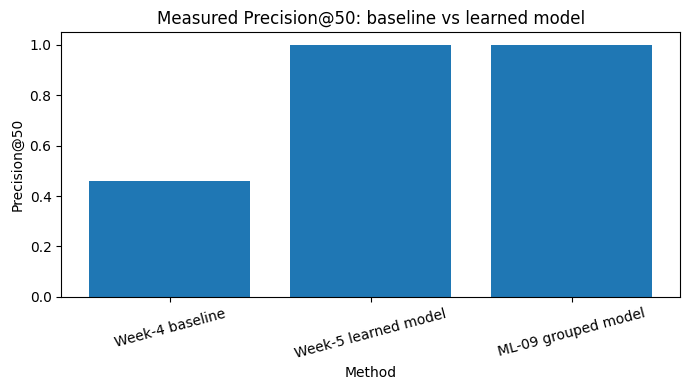

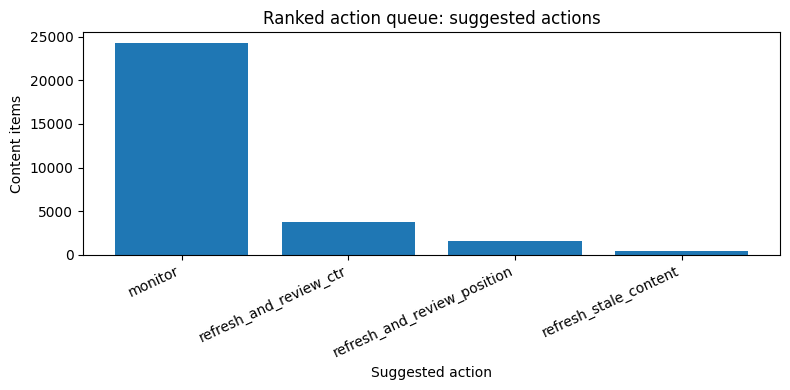


Artifacts created:
work/outputs/capstone_ranked_action_queue.csv -> True
work/outputs/capstone_results.csv -> True
work/outputs/capstone_precision_at_50.png -> True
work/outputs/capstone_action_distribution.png -> True


In [14]:
# Capstone Section 7: Artifacts for the paper

from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Artifact 1: Export ranked queue
# ---------------------------------------------------------

paper_queue = queue[
    [
        "baseline_rank",
        "content_id",
        "baseline_action_score",
        "reason_codes",
        "suggested_action"
    ]
].copy()

queue_path = output_dir / "capstone_ranked_action_queue.csv"

paper_queue.to_csv(
    queue_path,
    index=False
)

# ---------------------------------------------------------
# Artifact 2: Model vs baseline table
# ---------------------------------------------------------

results_table = pd.DataFrame({
    "method": [
        "Week-4 baseline",
        "Week-5 learned model",
        "ML-09 grouped model"
    ],
    "precision_at_50": [
        0.46,
        1.00,
        honest_precision
    ]
})

results_path = output_dir / "capstone_results.csv"

results_table.to_csv(
    results_path,
    index=False
)

# ---------------------------------------------------------
# Artifact 3: Results figure
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(
    results_table["method"],
    results_table["precision_at_50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.title("Measured Precision@50: baseline vs learned model")

plt.ylim(0, 1.05)
plt.xticks(rotation=15)

plt.tight_layout()

results_fig = output_dir / "capstone_precision_at_50.png"

plt.savefig(
    results_fig,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# Artifact 4: Suggested-action distribution
# ---------------------------------------------------------

action_counts = (
    queue["suggested_action"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))

plt.bar(
    action_counts.index,
    action_counts.values
)

plt.ylabel("Content items")
plt.xlabel("Suggested action")
plt.title("Ranked action queue: suggested actions")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

action_fig = output_dir / "capstone_action_distribution.png"

plt.savefig(
    action_fig,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------

print("\nArtifacts created:")

for path in [
    queue_path,
    results_path,
    results_fig,
    action_fig
]:
    print(path, "->", path.exists())

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
